# Cross-validation and model comparison

This notebook compares logistic regression, random forest, and histogram
gradient boosting using stratified five-fold cross-validation.

Cross-validation is used to determine whether model performance remains
stable across different subsets of the training data.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_validate

from predictive_maintenance.data import load_data
from predictive_maintenance.evaluate import calculate_metrics
from predictive_maintenance.features import create_features
from predictive_maintenance.train import (
    create_gradient_boosting_model,
    create_logistic_model,
    create_random_forest_model,
    split_data,
)

In [3]:
df = load_data()
X, y = create_features(df)

X_train, X_test, y_train, y_test = split_data(X, y)

print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")
print(f"Training failures: {y_train.sum()}")
print(f"Test failures: {y_test.sum()}")

Loading local dataset from /Users/alexanderkorolev/Desktop/predictive-maintenance-ai4i/data/raw/ai4i2020.csv
Training observations: 8000
Test observations: 2000
Training failures: 271
Test failures: 68


In [4]:
models = {
    "Logistic regression": create_logistic_model(X_train),
    "Random forest": create_random_forest_model(X_train),
    "Gradient boosting": create_gradient_boosting_model(X_train),
}

In [5]:
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1_score": "f1",
    "pr_auc": "average_precision",
}

In [6]:
rows = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cross_validation,
        scoring=scoring,
        n_jobs=-1,
    )

    rows.append(
        {
            "model": model_name,
            "precision_mean": scores["test_precision"].mean(),
            "precision_std": scores["test_precision"].std(),
            "recall_mean": scores["test_recall"].mean(),
            "recall_std": scores["test_recall"].std(),
            "f1_mean": scores["test_f1_score"].mean(),
            "f1_std": scores["test_f1_score"].std(),
            "pr_auc_mean": scores["test_pr_auc"].mean(),
            "pr_auc_std": scores["test_pr_auc"].std(),
        }
    )

cv_results = pd.DataFrame(rows)
cv_results.set_index("model").round(3)

,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,pr_auc_mean,pr_auc_std
model,,,,,,,,
Logistic regression,0.137,0.005,0.804,0.067,0.235,0.010,0.441,0.030
Random forest,0.797,0.057,0.513,0.038,0.623,0.039,0.742,0.032
Gradient boosting,0.518,0.037,0.841,0.028,0.641,0.031,0.786,0.038


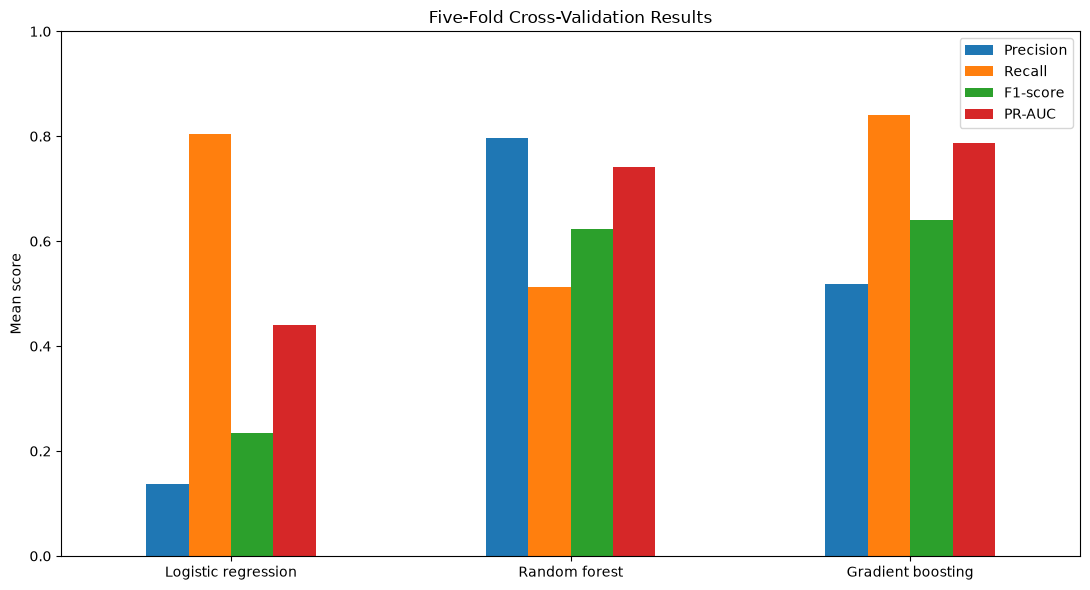

In [7]:
plot_results = (
    cv_results.set_index("model")[
        [
            "precision_mean",
            "recall_mean",
            "f1_mean",
            "pr_auc_mean",
        ]
    ]
    .rename(
        columns={
            "precision_mean": "Precision",
            "recall_mean": "Recall",
            "f1_mean": "F1-score",
            "pr_auc_mean": "PR-AUC",
        }
    )
)

plot_results.plot(
    kind="bar",
    figsize=(11, 6),
)

plt.title("Five-Fold Cross-Validation Results")
plt.ylabel("Mean score")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [8]:
best_model_name = cv_results.loc[
    cv_results["pr_auc_mean"].idxmax(),
    "model",
]

print(f"Best model by mean PR-AUC: {best_model_name}")

Best model by mean PR-AUC: Gradient boosting


In [9]:
best_model = models[best_model_name]

best_model.fit(
    X_train,
    y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Type','Air temperature','Process temperature','Rotational speed', 'Torque','Tool wear']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [10]:
test_metrics = calculate_metrics(
    best_model,
    X_test,
    y_test,
)

pd.Series(test_metrics).round(3)

accuracy     0.969
precision    0.527
recall       0.853
f1_score     0.652
pr_auc       0.814
dtype: float64

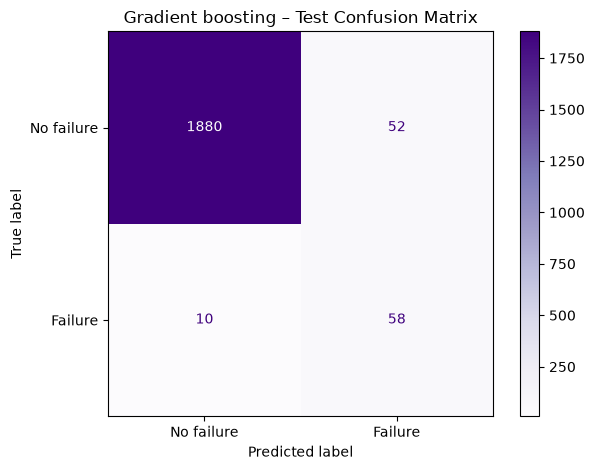

In [11]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["No failure", "Failure"],
    cmap="Purples",
)

plt.title(f"{best_model_name} – Test Confusion Matrix")
plt.tight_layout()
plt.show()

## Interpretation

The cross-validation results show that gradient boosting achieves the highest
mean PR-AUC and the highest recall among the tree-based models. Random forest
provides higher precision, but detects a smaller proportion of machine
failures.

On the test set, gradient boosting correctly detects 58 of 68 failures,
corresponding to a recall of approximately 85.3%. It generates 52 false
alarms and misses 10 failures. Its precision is approximately 52.7%, while
the F1-score is approximately 65.2%.

Gradient boosting therefore provides the strongest overall balance between
failure detection and alarm reliability. However, the final model should be
selected after applying the same cost-based threshold optimization to both
gradient boosting and random forest.